Effect of Depth in Multilayer Perceptron (MLP)
GitHub : https://github.com/Bhavana-Prasad/mlp-depth-analysis.git

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [6]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

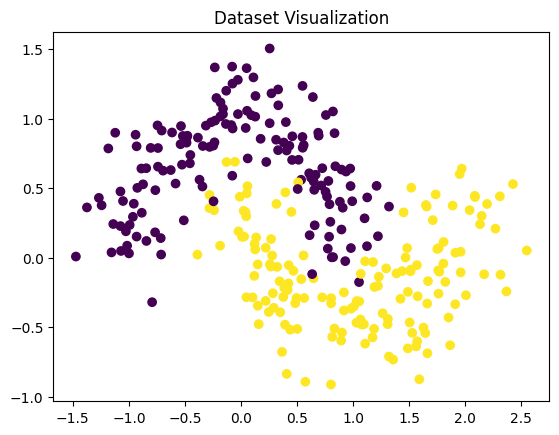

In [16]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Dataset Visualization")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Shallow (1 layer)": MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42),
    "Medium (2 layers)": MLPClassifier(hidden_layer_sizes=(10,10), max_iter=2000, random_state=42),
    "Deep (5 layers)": MLPClassifier(hidden_layer_sizes=(10,10,10,10,10), max_iter=2000, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    results[name] = (train_acc, test_acc)
    
    print(name)
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("----------------------")

Shallow (1 layer)
Train Accuracy: 0.8714285714285714
Test Accuracy: 0.8888888888888888
----------------------
Medium (2 layers)
Train Accuracy: 0.8952380952380953
Test Accuracy: 0.9111111111111111
----------------------
Deep (5 layers)
Train Accuracy: 0.9666666666666667
Test Accuracy: 0.9666666666666667
----------------------


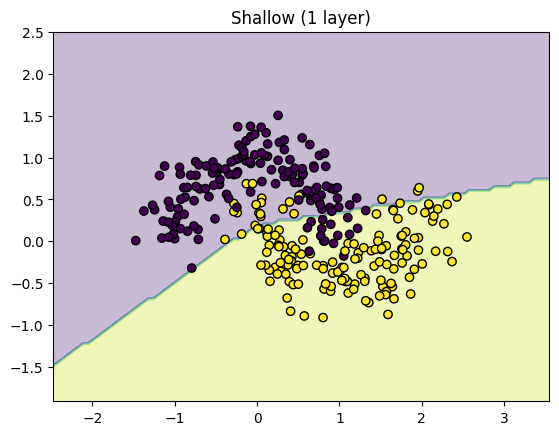

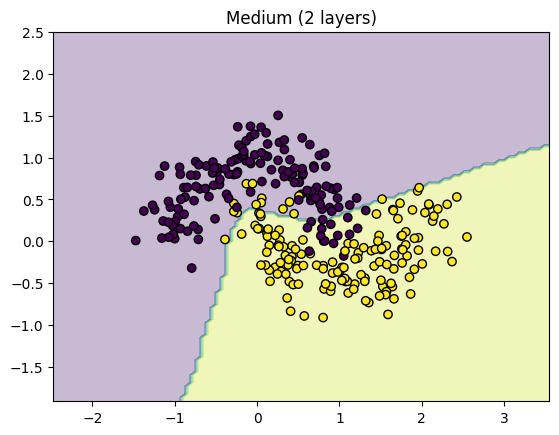

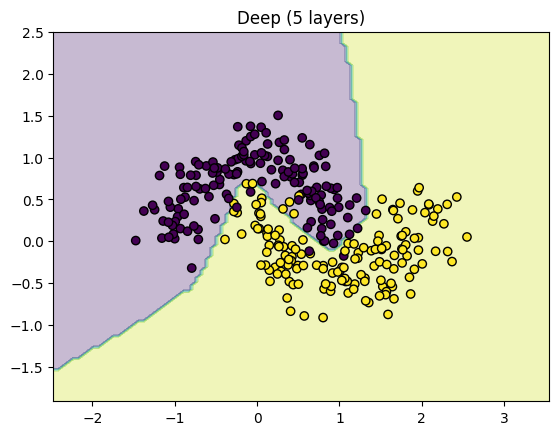

In [19]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

for name, model in models.items():
    plot_decision_boundary(model, X, y, name)

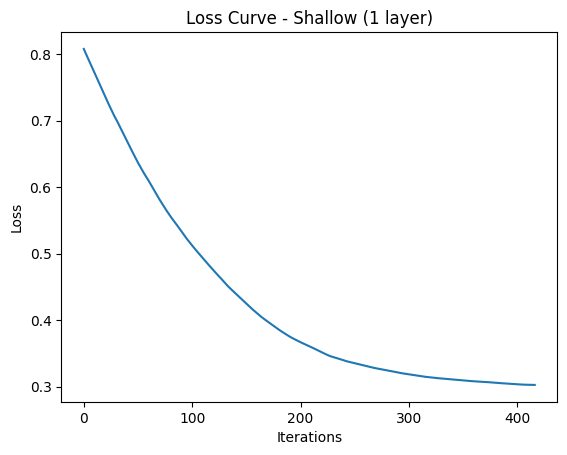

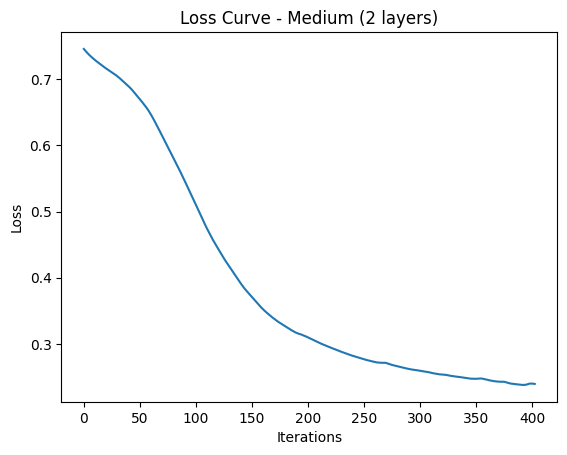

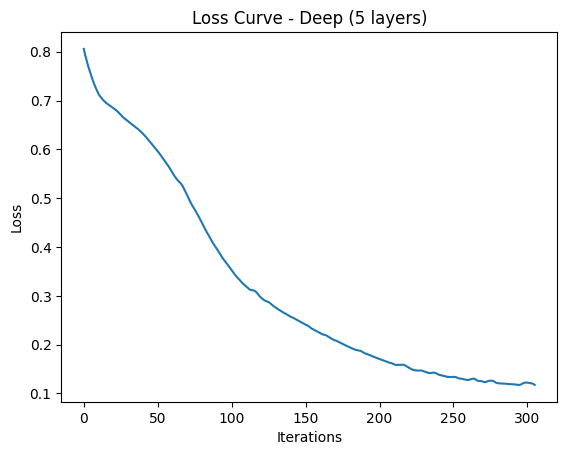

In [21]:
for name, model in models.items():
    plt.figure()
    plt.plot(model.loss_curve_)
    plt.title(f"Loss Curve - {name}")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

In [11]:
for name, (train, test) in results.items():
    print(f"{name}: Train={train:.3f}, Test={test:.3f}")

Shallow (1 layer): Train=0.871, Test=0.889
Medium (2 layers): Train=0.895, Test=0.911
Deep (5 layers): Train=0.967, Test=0.967
